//Decision Tree Visualisation Using AI

In [92]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [93]:
# 1. Load a sample dataset (iris dataset)
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset loaded: Iris dataset")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")
print(f"Number of samples: {X.shape[0]}")

Dataset loaded: Iris dataset
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Number of samples: 150


In [94]:
# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
print(f"\nSplit data into {X_train.shape[0]} training samples and {X_test.shape[0]} testing samples")


Split data into 120 training samples and 30 testing samples


In [95]:
# 3. Create and train the decision tree classifier
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_classifier.fit(X_train, y_train)
print("\nDecision tree trained with max_depth=3")


Decision tree trained with max_depth=3


In [96]:
# 4. Make predictions
y_pred = dt_classifier.predict(X_test)
print("\nMade predictions on test data")


Made predictions on test data


In [97]:
# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Model accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Model accuracy: 0.9333 (93.33%)


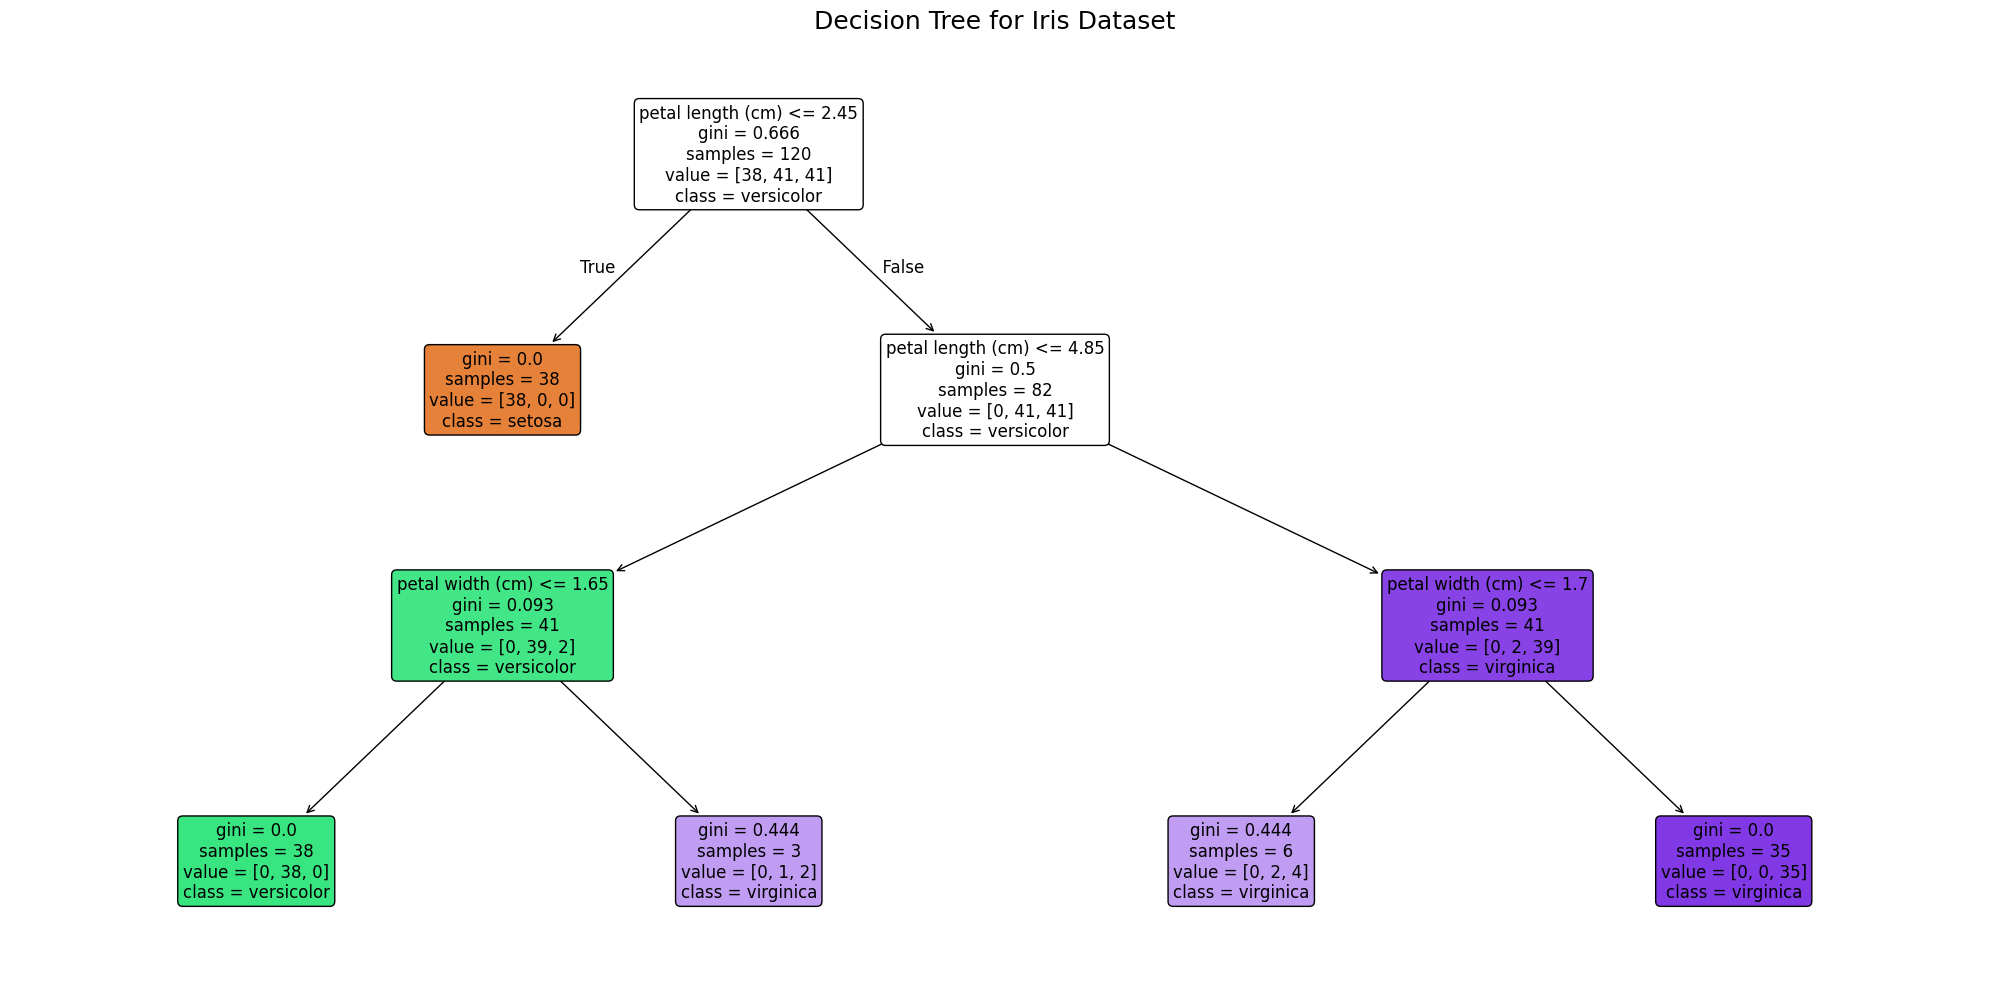

In [98]:
# 6. Visualize the decision tree
plt.figure(figsize=(20, 10))
tree.plot_tree(dt_classifier, feature_names=feature_names, class_names=target_names, 
              filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree for Iris Dataset", fontsize=18)
plt.tight_layout()
plt.show()

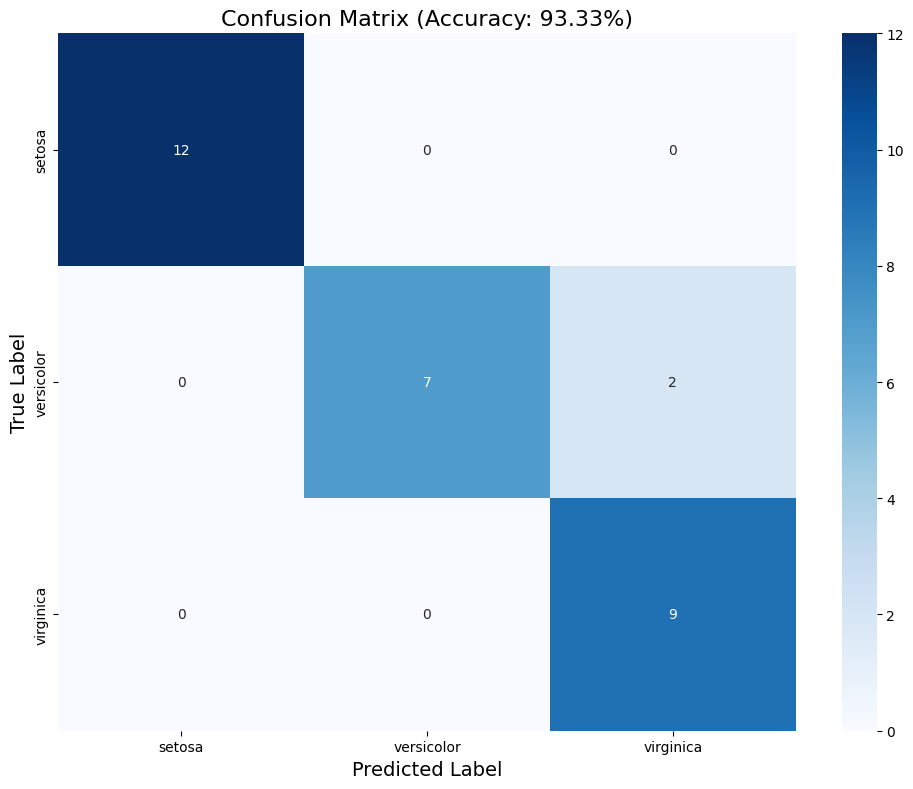

In [99]:
# 7. Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix (Accuracy: {:.2f}%)'.format(accuracy * 100), fontsize=16)
plt.tight_layout()
plt.show()

In [100]:
# 8. Feature importance visualization
plt.figure(figsize=(10, 6))
importances = dt_classifier.feature_importances_
indices = np.argsort(importances)[::-1]

<Figure size 1000x600 with 0 Axes>

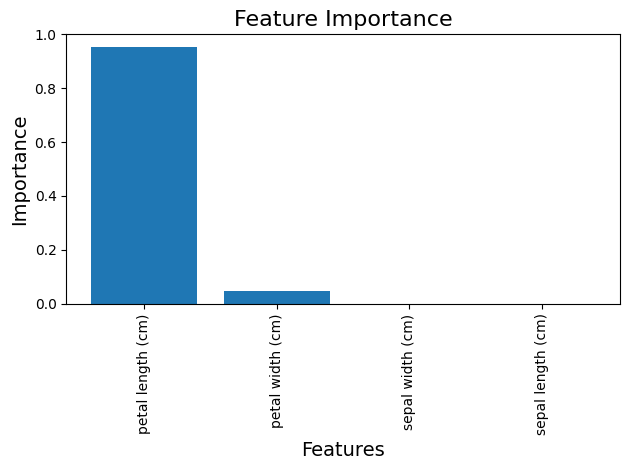

In [101]:
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Feature Importance', fontsize=16)
plt.tight_layout()
plt.show()

In [102]:
# 9. Decision boundary visualization (for 2 features)
def plot_decision_boundary(model, X, y, feature_idx=[0, 2]):
    # Extract the two features we want to visualize
    X_visual = X[:, feature_idx]
    
    # Train a new classifier using only these two features
    model_2d = DecisionTreeClassifier(max_depth=3, random_state=42)
    model_2d.fit(X_train[:, feature_idx], y_train)
    
    # Create a mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X_visual[:, 0].min() - 1, X_visual[:, 0].max() + 1
    y_min, y_max = X_visual[:, 1].min() - 1, X_visual[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Plot the decision boundary
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(12, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='rainbow')
    
    # Plot the training points
    scatter = plt.scatter(X_visual[:, 0], X_visual[:, 1], c=y, cmap='rainbow', edgecolor='k', s=100)
    
    plt.xlabel(feature_names[feature_idx[0]], fontsize=14)
    plt.ylabel(feature_names[feature_idx[1]], fontsize=14)
    plt.title('Decision Boundary', fontsize=16)
    plt.legend(handles=scatter.legend_elements()[0], labels=target_names)
    plt.tight_layout()
    plt.show()
    
    # Show the tree for this 2D projection
    plt.figure(figsize=(15, 8))
    tree.plot_tree(model_2d, feature_names=[feature_names[i] for i in feature_idx], 
                  class_names=target_names, filled=True, rounded=True)
    plt.title(f'Decision Tree Using Only {feature_names[feature_idx[0]]} and {feature_names[feature_idx[1]]}', fontsize=14)
    plt.tight_layout()
    plt.show()

print("\nGenerating decision boundary visualization...")


Generating decision boundary visualization...


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

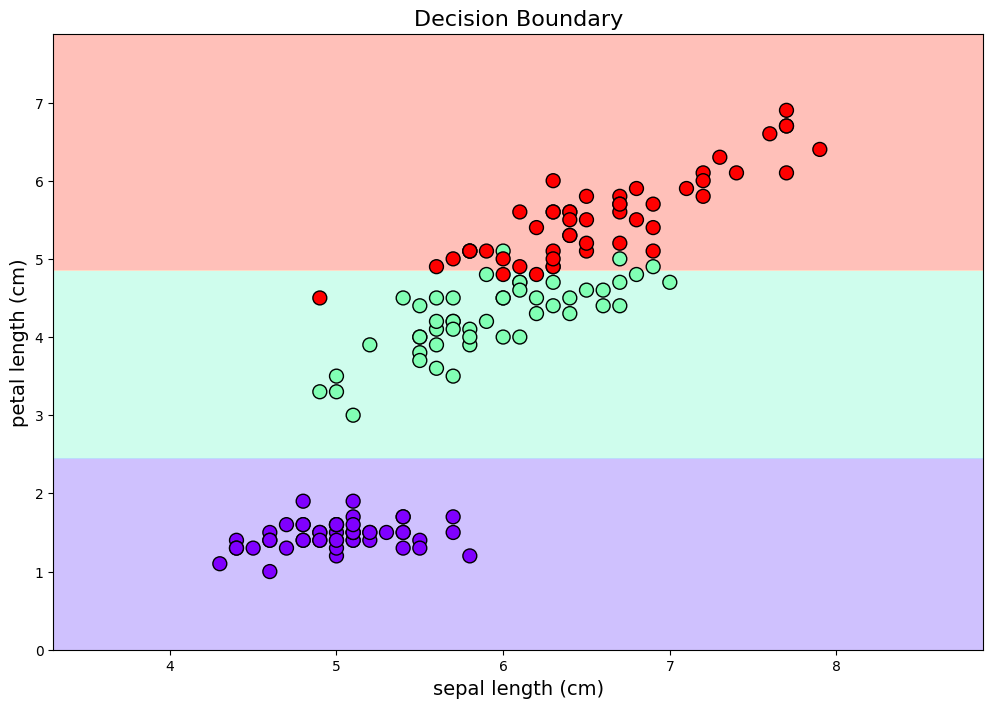

In [103]:
# 10. Create decision boundary visualization
plot_decision_boundary(dt_classifier, X, y)


In [ ]:
# 11. Path visualization for a sample
def visualize_prediction_path(model, instance, feature_names, class_names):
    # Get the decision path for the instance
    decision_path = model.decision_path([instance])
    
    # Get the node feature, threshold and impurity
    tree_structure = model.tree_
    
    # Get the nodes that are in the decision path
    path_nodes = decision_path.indices[decision_path.indptr[0]:decision_path.indptr[1]]
    
    result = ["Decision Path for Sample:"]
    result.append(f"Sample features: {dict(zip(feature_names, instance))}")
    
    for node_id in path_nodes:
        if tree_structure.children_left[node_id] == -1:  # Leaf node
            class_idx = np.argmax(tree_structure.value[node_id][0])
            result.append(f"  → Final prediction: {class_names[class_idx]}")
        else:  # Decision node
            feature_idx = tree_structure.feature[node_id]
            threshold = tree_structure.threshold[node_id]
            
            if instance[feature_idx] <= threshold:
                direction = "≤"
                next_node = tree_structure.children_left[node_id]
            else:
                direction = ">"
                next_node = tree_structure.children_right[node_id]
            
            result.append(f"  → If {feature_names[feature_idx]} ({instance[feature_idx]:.2f}) {direction} {threshold:.2f} → Go to node {next_node}")
    
    return "\n".join(result)


In [ ]:
# 12. Visualize the decision path for a sample instance
print("\nTracing the prediction path for a sample instance:")
sample_idx = 10
sample_instance = X_test[sample_idx]
path_explanation = visualize_prediction_path(dt_classifier, sample_instance, feature_names, target_names)
print(path_explanation)
print(f"True class: {target_names[y_test[sample_idx]]}")
print(f"Predicted class: {target_names[y_pred[sample_idx]]}")


Tracing the prediction path for a sample instance:
Decision Path for Sample:
Sample features: {'sepal length (cm)': np.float64(6.5), 'sepal width (cm)': np.float64(3.2), 'petal length (cm)': np.float64(5.1), 'petal width (cm)': np.float64(2.0)}
  → If petal length (cm) (5.10) > 2.45 → Go to node 2
  → If petal length (cm) (5.10) > 4.75 → Go to node 6
  → If petal width (cm) (2.00) > 1.75 → Go to node 8
  → Final prediction: virginica
True class: virginica
Predicted class: virginica


In [ ]:

# 13. Function to provide a simple explanation of how decision trees work
def explain_decision_trees():
    explanation = """
    How Decision Trees Work:
    
    1. Decision trees make predictions by asking a series of questions about the features.
    2. Each node in the tree represents a question (typically comparing a feature to a threshold).
    3. The tree splits the data at each node, trying to create subsets that are more "pure" in terms of the target variable.
    4. The splitting process uses metrics like Gini impurity or entropy to determine the best split.
    5. The tree continues growing until a stopping criterion is met (max depth, min samples per leaf, etc.).
    6. To make a prediction for a new instance, we follow the tree from the root to a leaf.
    7. The final prediction is typically the majority class in the leaf node.
    
    Key Concepts:
    - Splitting criteria: How the algorithm decides which feature to split on (Gini, entropy)
    - Pruning: Techniques to reduce overfitting by simplifying the tree
    - Feature importance: Which features the tree found most useful for classification
    - Decision boundaries: The regions in feature space that the tree assigns to different classes
    """
    return explanation

In [ ]:
# 14. Explain decision trees
print("\nUnderstanding Decision Trees:")
print(explain_decision_trees())

# Interactive example for user understanding
print("\n--- Interactive Example ---")
print("Let's manually classify a sample using the decision rules:")

# Get a sample instance and manually show how it would be classified
sample_idx = 15
sample_instance = X_test[sample_idx]
print(f"Sample features: {dict(zip(feature_names, sample_instance))}")

# Manually tracing the decision path
def manual_prediction(instance, dt_model, feature_names, target_names):
    node_id = 0  # Start from the root
    path_steps = []
    
    while dt_model.tree_.children_left[node_id] != -1:  # Until we reach a leaf
        feature_idx = dt_model.tree_.feature[node_id]
        threshold = dt_model.tree_.threshold[node_id]
        
        step = f"Question: Is {feature_names[feature_idx]} ({instance[feature_idx]:.2f}) <= {threshold:.2f}?"
        path_steps.append(step)
        
        if instance[feature_idx] <= threshold:
            response = f"Answer: Yes, go to left child."
            path_steps.append(response)
            node_id = dt_model.tree_.children_left[node_id]
        else:
            response = f"Answer: No, go to right child."
            path_steps.append(response)
            node_id = dt_model.tree_.children_right[node_id]
    
    # We've reached a leaf node
    class_distribution = dt_model.tree_.value[node_id][0]
    class_idx = np.argmax(class_distribution)
    
    conclusion = [
        f"Reached a leaf node. Class distribution: {class_distribution}",
        f"Prediction: {target_names[class_idx]}",
        f"True class: {target_names[y_test[sample_idx]]}"
    ]
    
    return path_steps + conclusion

# Run the manual prediction
print("\n".join(manual_prediction(sample_instance, dt_classifier, feature_names, target_names)))



Understanding Decision Trees:

    How Decision Trees Work:
    
    1. Decision trees make predictions by asking a series of questions about the features.
    2. Each node in the tree represents a question (typically comparing a feature to a threshold).
    3. The tree splits the data at each node, trying to create subsets that are more "pure" in terms of the target variable.
    4. The splitting process uses metrics like Gini impurity or entropy to determine the best split.
    5. The tree continues growing until a stopping criterion is met (max depth, min samples per leaf, etc.).
    6. To make a prediction for a new instance, we follow the tree from the root to a leaf.
    7. The final prediction is typically the majority class in the leaf node.
    
    Key Concepts:
    - Splitting criteria: How the algorithm decides which feature to split on (Gini, entropy)
    - Pruning: Techniques to reduce overfitting by simplifying the tree
    - Feature importance: Which features the tree 

In [ ]:
# 15. Print out the structure of the tree in a more readable format
def print_tree_structure(tree_model, feature_names, class_names, indent=0):
    tree_ = tree_model.tree_
    
    def print_node(node_id, indent):
        indent_str = "  " * indent
        
        if tree_.children_left[node_id] == tree_.children_right[node_id]:  # Leaf node
            class_counts = tree_.value[node_id][0]
            class_probs = class_counts / np.sum(class_counts)
            majority_class = np.argmax(class_counts)
            return [f"{indent_str}Leaf: predict {class_names[majority_class]} "
                  f"(probability: {class_probs[majority_class]:.2f}, samples: {np.sum(class_counts):.0f})"]
        else:  # Decision node
            feature_idx = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]
            impurity = tree_.impurity[node_id]
            samples = np.sum(tree_.value[node_id][0])
            
            result = [
                f"{indent_str}Node {node_id}: If {feature_names[feature_idx]} <= {threshold:.2f}",
                f"{indent_str}  gini: {impurity:.2f}, samples: {samples:.0f}"
            ]
            
            result.append(f"{indent_str}  Left child (<=):")
            result.extend(print_node(tree_.children_left[node_id], indent + 2))
            
            result.append(f"{indent_str}  Right child (>):")
            result.extend(print_node(tree_.children_right[node_id], indent + 2))
            
            return result
    
    lines = ["Decision Tree Structure:"]
    lines.extend(print_node(0, indent))
    return "\n".join(lines)

# Print a text representation of the tree
print("\n--- Tree Structure ---")
print(print_tree_structure(dt_classifier, feature_names, target_names))


--- Tree Structure ---
Decision Tree Structure:
Node 0: If petal length (cm) <= 2.45
  gini: 0.66, samples: 1
  Left child (<=):
    Leaf: predict setosa (probability: 1.00, samples: 1)
  Right child (>):
    Node 2: If petal length (cm) <= 4.75
      gini: 0.50, samples: 1
      Left child (<=):
        Node 3: If petal width (cm) <= 1.60
          gini: 0.06, samples: 1
          Left child (<=):
            Leaf: predict versicolor (probability: 1.00, samples: 1)
          Right child (>):
            Leaf: predict virginica (probability: 1.00, samples: 1)
      Right child (>):
        Node 6: If petal width (cm) <= 1.75
          gini: 0.21, samples: 1
          Left child (<=):
            Leaf: predict versicolor (probability: 0.50, samples: 1)
          Right child (>):
            Leaf: predict virginica (probability: 0.97, samples: 1)



Comparing trees with different max_depth values...


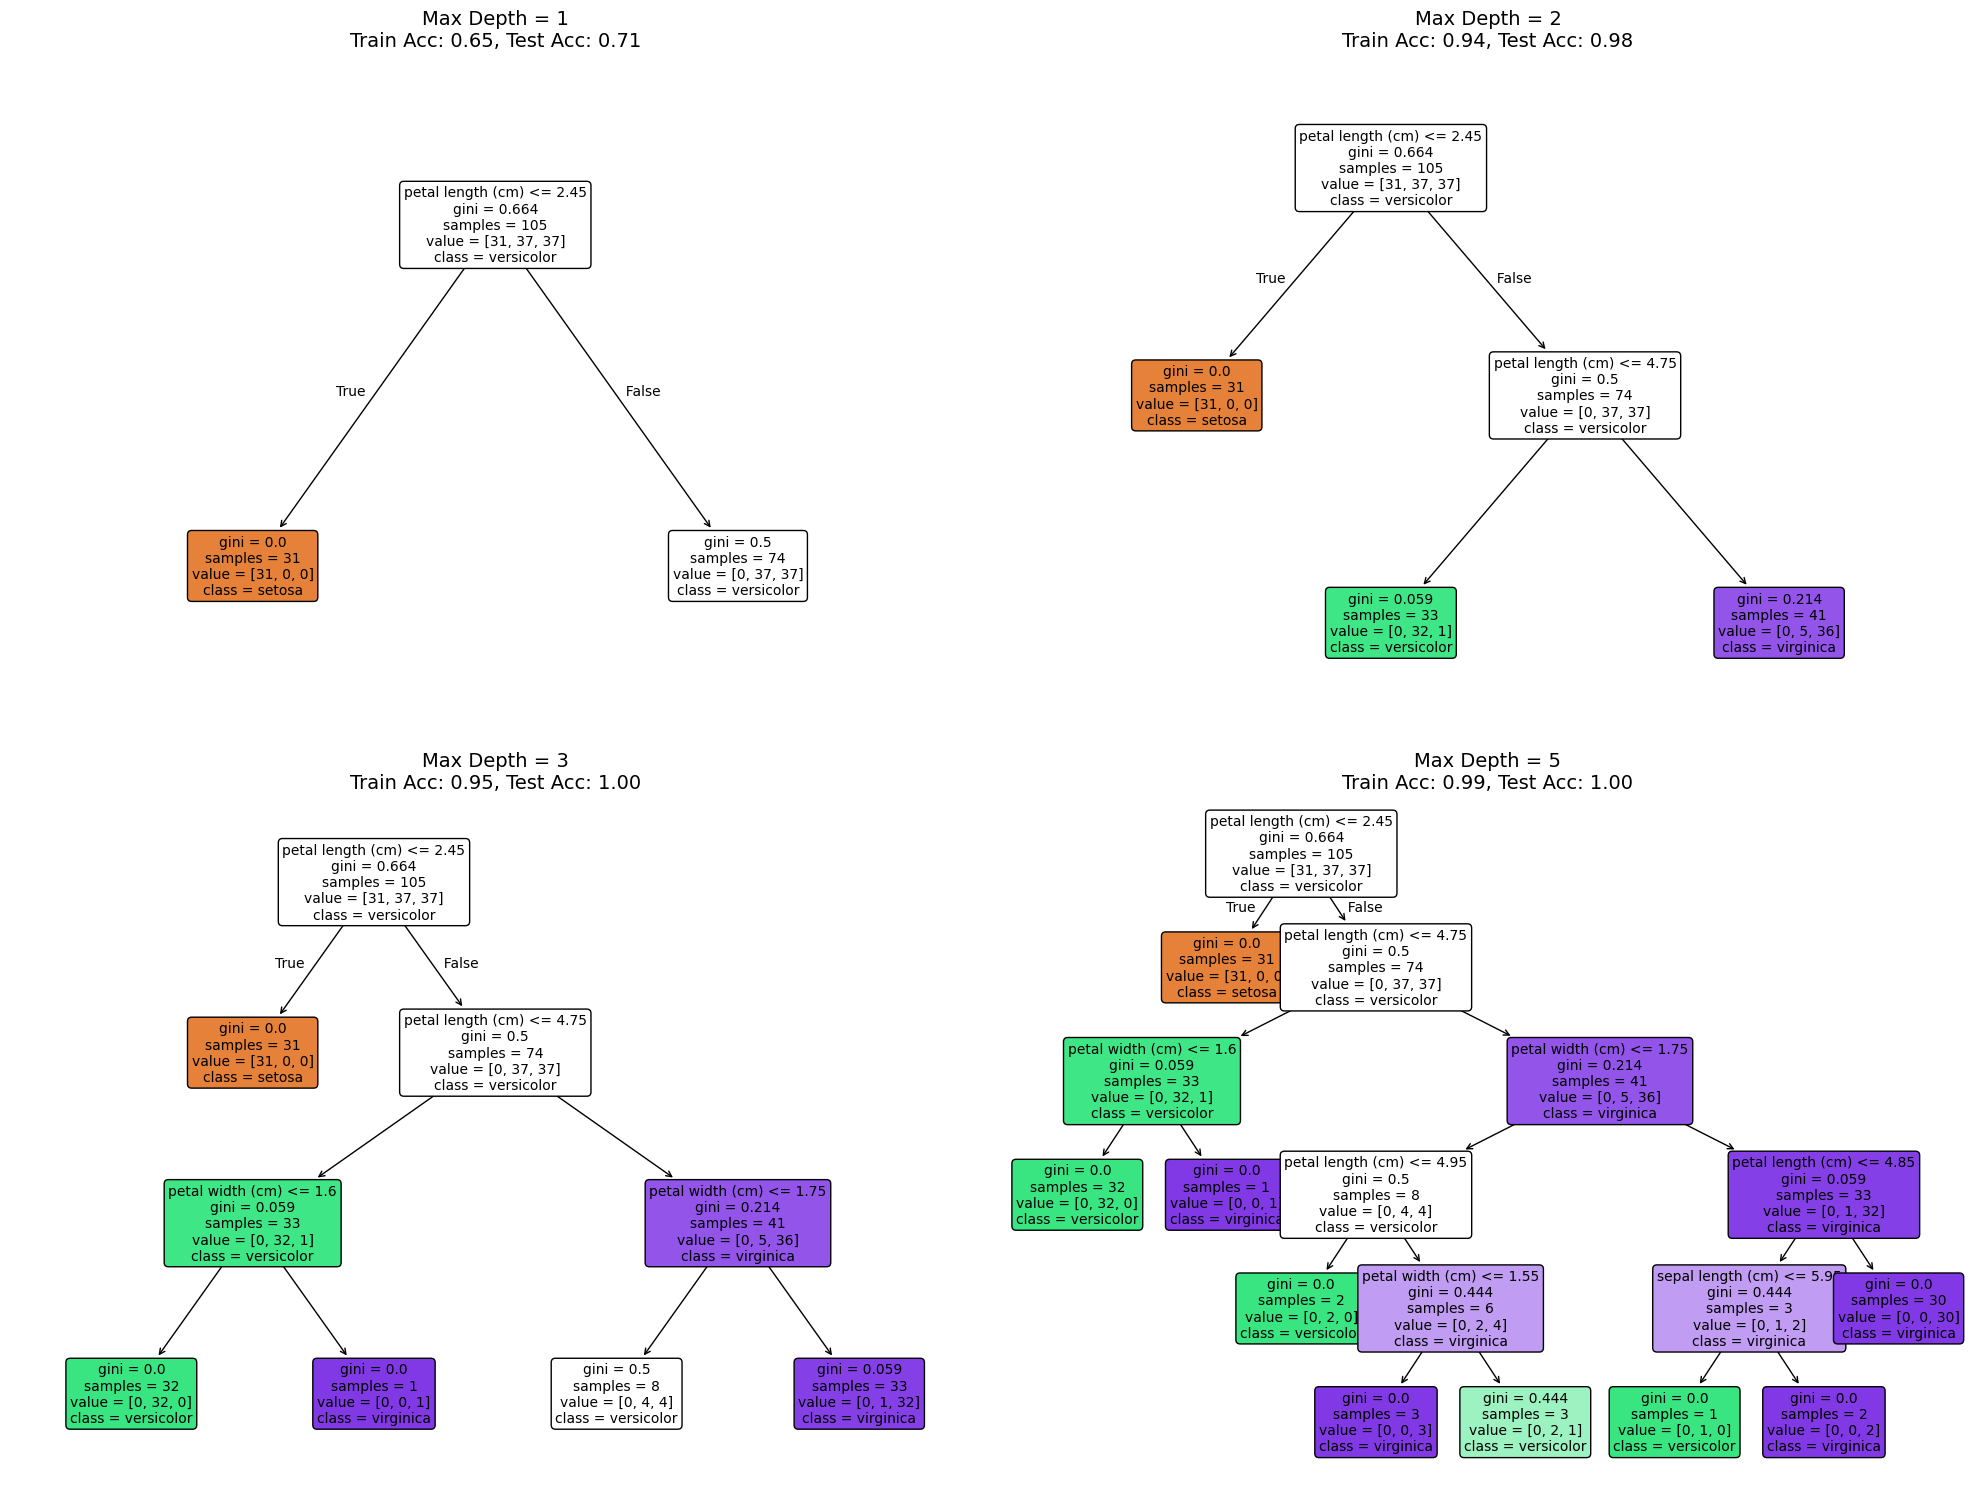

In [ ]:
# 16. Visualize different decision trees with varying max_depth
def visualize_max_depth_impact(X, y, feature_names, target_names, depths=[1, 2, 3, 5]):
    plt.figure(figsize=(20, 15))
    
    for i, depth in enumerate(depths):
        # Train model with specific depth
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        
        # Calculate accuracy
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        
        # Plot tree
        plt.subplot(2, 2, i+1)
        tree.plot_tree(model, feature_names=feature_names, class_names=target_names,
                      filled=True, rounded=True, fontsize=10)
        plt.title(f'Max Depth = {depth}\nTrain Acc: {train_acc:.2f}, Test Acc: {test_acc:.2f}', fontsize=14)
    
    plt.tight_layout()
    plt.show()

print("\nComparing trees with different max_depth values...")
visualize_max_depth_impact(X, y, feature_names, target_names)

In [105]:

# 17. Interactive sliders for hyperparameters (in a separate cell if needed)
# Note: To use this, you'll need ipywidgets installed: pip install ipywidgets
print("\nFor interactive exploration, you can use the following code in a separate cell:")
print("""
from ipywidgets import interact, IntSlider, FloatSlider

@interact(
    max_depth=IntSlider(min=1, max=10, step=1, value=3, description='Max Depth:'),
    min_samples_split=IntSlider(min=2, max=20, step=1, value=2, description='Min Samples Split:'),
    min_samples_leaf=IntSlider(min=1, max=10, step=1, value=1, description='Min Samples Leaf:')
)
def explore_tree_params(max_depth=3, min_samples_split=2, min_samples_leaf=1):
    # Train model with given parameters
    model = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Calculate accuracies
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Testing accuracy: {test_acc:.4f}")
    
    # Visualize the tree
    plt.figure(figsize=(20, 10))
    tree.plot_tree(model, feature_names=feature_names, class_names=target_names, 
                 filled=True, rounded=True, fontsize=12)
    plt.title(f"Decision Tree (max_depth={max_depth}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf})", 
              fontsize=16)
    plt.tight_layout()
    plt.show()
""")


For interactive exploration, you can use the following code in a separate cell:

from ipywidgets import interact, IntSlider, FloatSlider

@interact(
    max_depth=IntSlider(min=1, max=10, step=1, value=3, description='Max Depth:'),
    min_samples_split=IntSlider(min=2, max=20, step=1, value=2, description='Min Samples Split:'),
    min_samples_leaf=IntSlider(min=1, max=10, step=1, value=1, description='Min Samples Leaf:')
)
def explore_tree_params(max_depth=3, min_samples_split=2, min_samples_leaf=1):
    # Train model with given parameters
    model = DecisionTreeClassifier(
        max_depth=max_depth, 
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Calculate accuracies
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f"Trainin